# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [3]:

df = pd.read_csv('./data/comprar_alquilar.csv')


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB
None


In [5]:
print(df.describe())

          ingresos  gastos_comunes  pago_coche  gastos_otros       ahorros  \
count   202.000000      202.000000  202.000000    202.000000    202.000000   
mean   4958.995050      971.584158  211.742574    515.425743  38749.668317   
std    1682.862556      272.106351  124.940754    168.103075  17365.231870   
min    2008.000000      384.000000    0.000000    201.000000  10319.000000   
25%    3513.750000      766.750000   99.000000    383.250000  24964.250000   
50%    4947.500000      968.000000  208.500000    522.500000  38523.000000   
75%    6374.500000     1165.250000  318.750000    656.750000  52150.750000   
max    7984.000000     1585.000000  448.000000    828.000000  69934.000000   

            vivienda  estado_civil       hijos     trabajo     comprar  
count     202.000000    202.000000  202.000000  202.000000  202.000000  
mean   373349.638614      1.024752    1.232673    4.490099    0.331683  
std    136371.525622      0.837184    1.367833    2.535794    0.471988  
min  

In [6]:
print(df.isnull().sum().sum())

0


In [7]:
df.value_counts('estado_civil')


estado_civil
2    73
0    68
1    61
Name: count, dtype: int64

In [8]:
df.value_counts('trabajo')


trabajo
5    31
8    29
7    27
6    23
3    21
4    19
2    18
1    18
0    16
Name: count, dtype: int64

In [10]:
df.groupby('trabajo')['ingresos'].mean()

trabajo
0    5393.750000
1    4665.666667
2    4533.166667
3    5341.761905
4    5109.368421
5    5139.032258
6    4940.391304
7    4704.148148
8    4849.379310
Name: ingresos, dtype: float64

In [11]:
df.corr('pearson')

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
ingresos,1.000000,0.560211,-0.109780,-0.124105,0.712889,0.614721,-0.042556,-0.024483,-0.038852,0.467123
gastos_comunes,0.560211,1.000000,-0.054400,-0.099881,0.209414,0.204781,-0.057152,-0.072321,-0.079095,0.200191
pago_coche,-0.109780,-0.054400,1.000000,0.010602,-0.193299,-0.094631,0.052239,-0.044858,0.018946,-0.196468
gastos_otros,-0.124105,-0.099881,0.010602,1.000000,-0.064384,-0.054577,-0.020226,0.124845,0.047313,-0.110330
ahorros,0.712889,0.209414,-0.193299,-0.064384,1.000000,0.605836,-0.063039,0.001445,-0.023829,0.340778
vivienda,0.614721,0.204781,-0.094631,-0.054577,0.605836,1.000000,-0.113420,-0.141924,-0.211790,-0.146092
estado_civil,-0.042556,-0.057152,0.052239,-0.020226,-0.063039,-0.113420,1.000000,0.507609,0.589512,0.142799
hijos,-0.024483,-0.072321,-0.044858,0.124845,0.001445,-0.141924,0.507609,1.000000,0.699916,0.272883
trabajo,-0.038852,-0.079095,0.018946,0.047313,-0.023829,-0.211790,0.589512,0.699916,1.000000,0.341537
comprar,0.467123,0.200191,-0.196468,-0.110330,0.340778,-0.146092,0.142799,0.272883,0.341537,1.000000


In [12]:
df['trabajo'].corr(df['ingresos'], method='pearson')

np.float64(-0.038852429219952744)

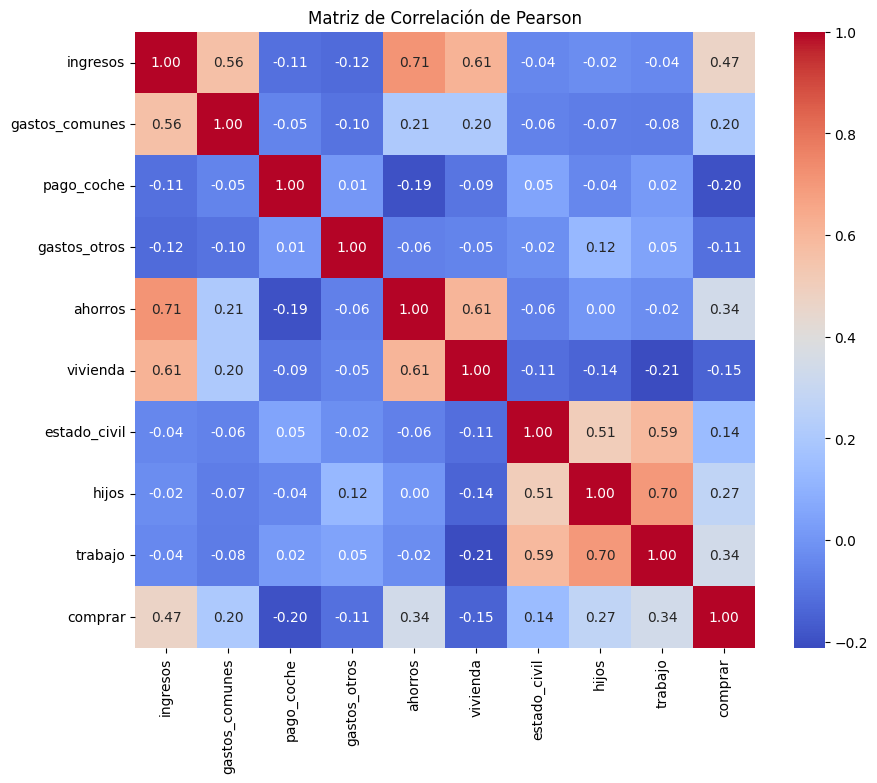

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Pearson')
plt.show()

### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

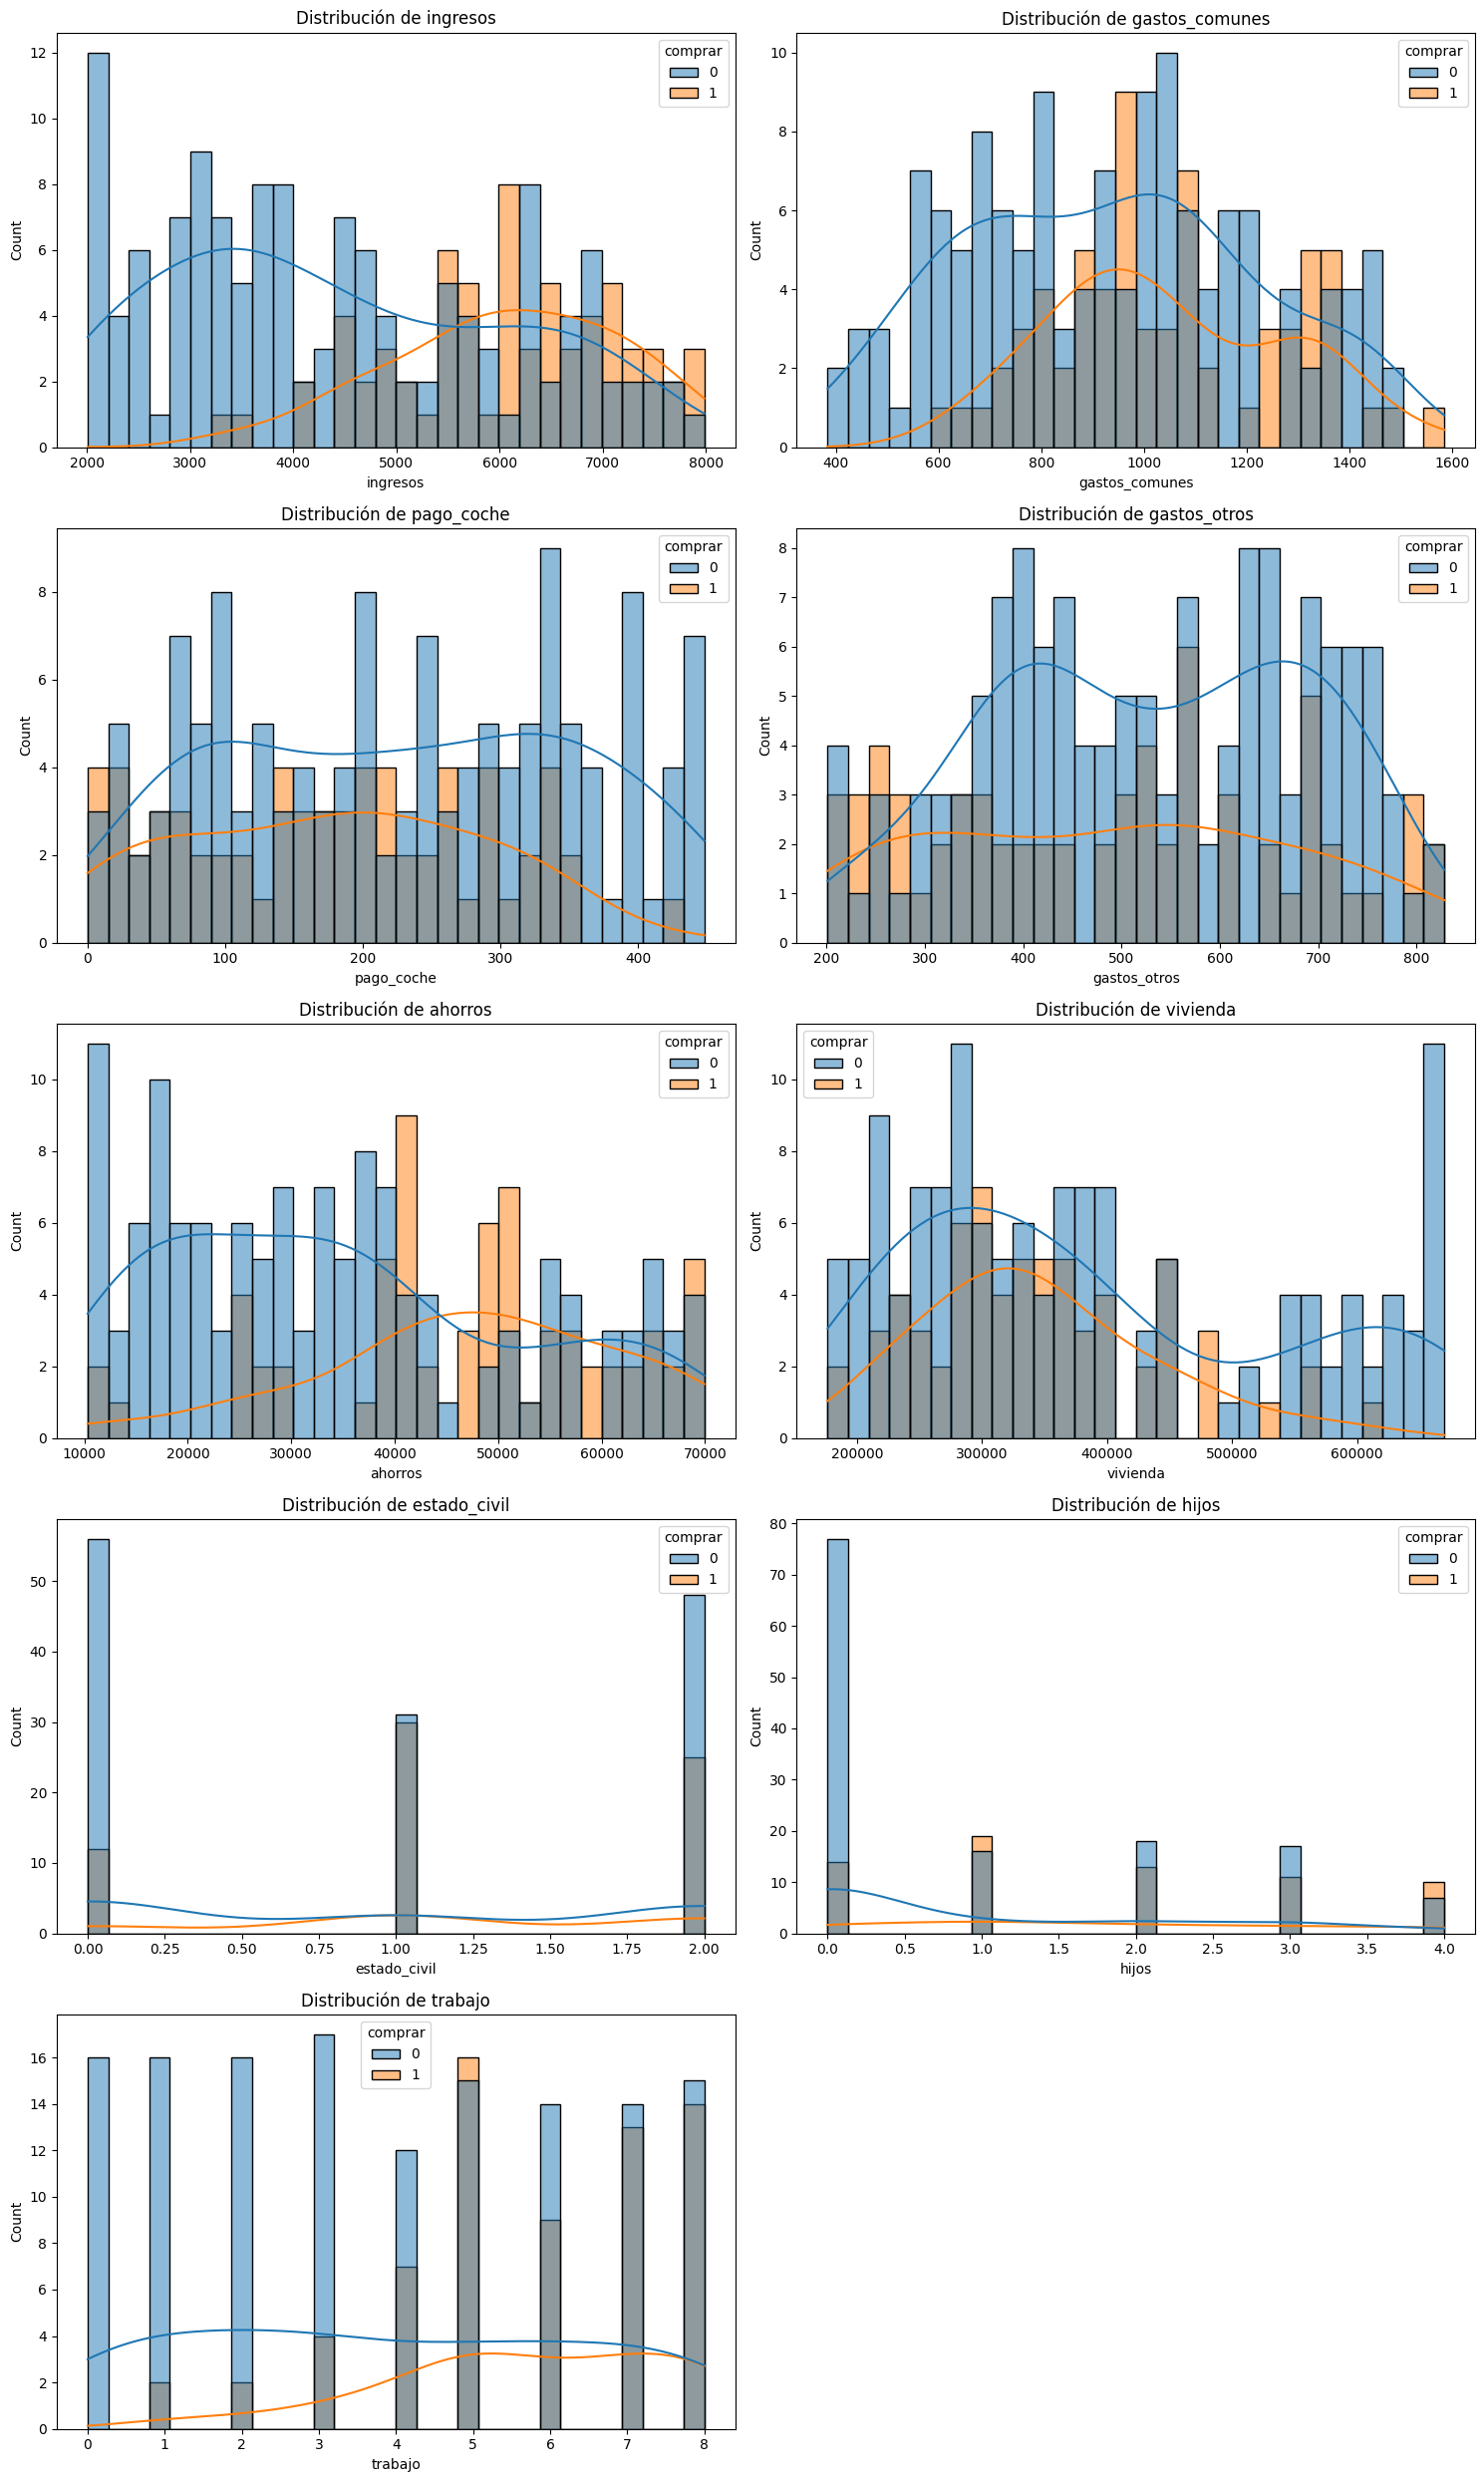

In [17]:
num_cols = df.select_dtypes(include='number').columns.drop('comprar', errors='ignore')

n_cols = 2
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='comprar', kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}')
    
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()

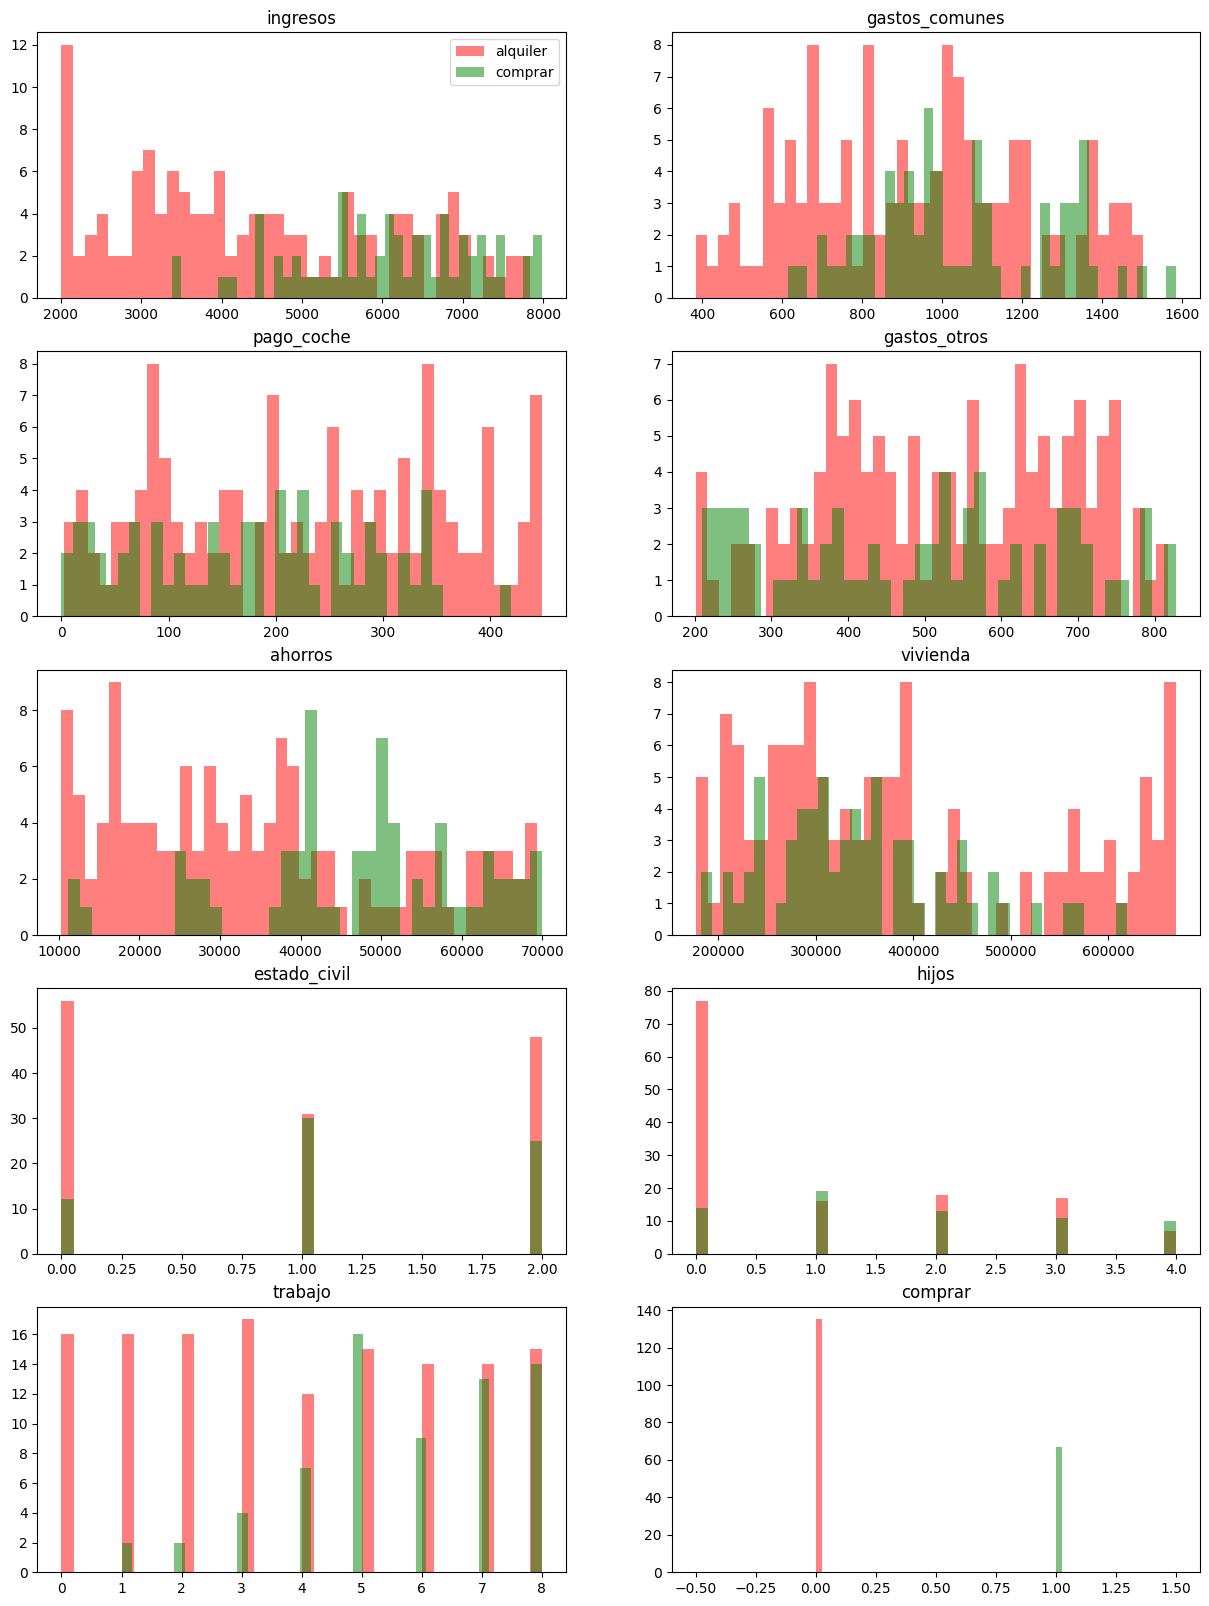

In [18]:
fig, axis = plt.subplots(5,2, figsize=(15,20))

alquiler = df[df['comprar']==0] 
comprar = df[df['comprar']==1] 

axes = axis.ravel()
for i in range(len(df.columns)):
    axes[i].hist(alquiler.values[:,i], bins=40, color = 'r', alpha=0.5)
    axes[i].hist(comprar.values[:,i], bins=40, color = 'g', alpha=0.5)
    axes[i].set_title(df.columns[i])

axes[0].legend(["alquiler", "comprar"])

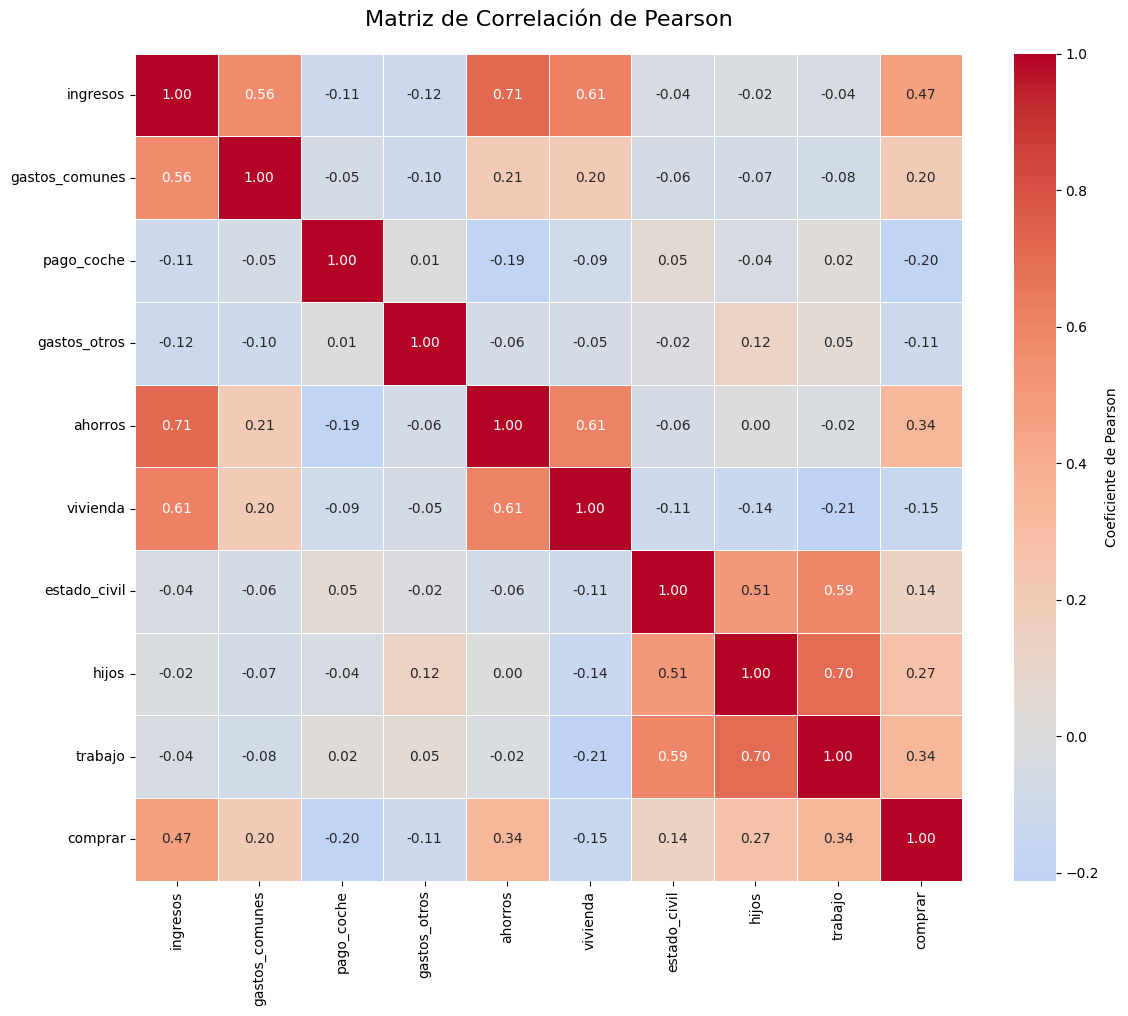

In [20]:
corr_matrix = df.corr(method='pearson')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True,           
            cmap='coolwarm',      
            fmt='.2f',            
            center=0,             
            square=True,          
            linewidths=0.5,       
            cbar_kws={'label': 'Coeficiente de Pearson'})

plt.title('Matriz de Correlación de Pearson', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [21]:

X = df.drop(columns=['comprar'])

y = df['comprar']

In [22]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled_df.head())
print(f"\n{X_scaled_df.mean().values[:3]}")
print(f"{X_scaled_df.std().values[:3]}")

   ingresos  gastos_comunes  pago_coche  gastos_otros   ahorros  vivienda  \
0  0.620129        0.104689   -1.698954      0.504359  0.649475  0.195910   
1  1.063927       -0.101625   -0.712042     -0.515401  0.259224  1.937370   
2  0.891173        0.226266   -0.912634      1.667244  1.080309 -0.379102   
3  1.274209        1.128886   -1.578599     -1.559015  0.909604  2.114062   
4  0.719611       -0.400042    0.090326      0.027279  0.159468 -0.179497   

   estado_civil     hijos   trabajo  
0     -1.227088  0.562374 -0.984420  
1     -0.029640  1.295273  0.596915  
2      1.167809 -0.170526  1.387582  
3     -1.227088 -0.903426 -0.589086  
4     -1.227088 -0.903426 -0.589086  

[-1.31907686e-16  9.01369188e-17  1.14319995e-16]
[1.00248448 1.00248448 1.00248448]


## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9)

X_pca = pca.fit_transform(X_scaled)

print("Shape después de PCA:", X_pca.shape)

print("Varianza explicada por cada PC:\n", pca.explained_variance_ratio_)

Shape después de PCA: (202, 9)
Varianza explicada por cada PC:
 [0.29913557 0.23294923 0.11711241 0.10685622 0.09635279 0.05629866
 0.04145579 0.03017819 0.01966115]


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

In [25]:
explained_variance = pca.explained_variance_ratio_

In [26]:
print("Varianza explicada por cada PC:")
for i, var in enumerate(explained_variance, 1):
    print(f"PC{i}: {var*100:.2f}%")

Varianza explicada por cada PC:
PC1: 29.91%
PC2: 23.29%
PC3: 11.71%
PC4: 10.69%
PC5: 9.64%
PC6: 5.63%
PC7: 4.15%
PC8: 3.02%
PC9: 1.97%


In [ ]:
cumulative_variance = np.cumsum(explained_variance)

print("Varianza explicada acumulada:")
for i, cum_var in enumerate(cumulative_variance, 1):
    print(f"PC1-PC{i}: {cum_var*100:.2f}%")

Varianza explicada acumulada:
PC1-PC1: 29.91%
PC1-PC2: 53.21%
PC1-PC3: 64.92%
PC1-PC4: 75.61%
PC1-PC5: 85.24%
PC1-PC6: 90.87%
PC1-PC7: 95.02%
PC1-PC8: 98.03%
PC1-PC9: 100.00%


In [ ]:
varianza_5_pc = cumulative_variance[4]

print(f"Los primeros 5 componentes explican: {varianza_5_pc*100:.2f}% de la varianza total")

Los primeros 5 componentes explican: 85.24% de la varianza total


### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

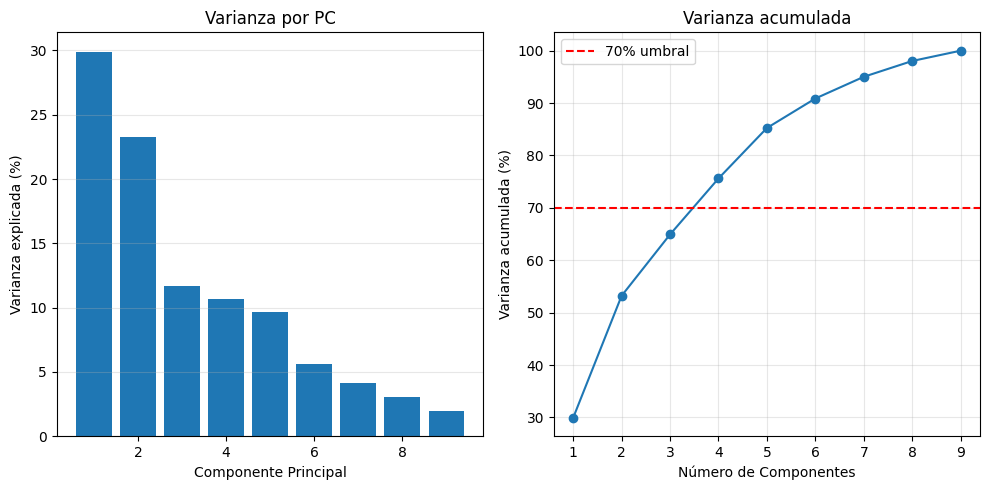

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))


plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance)+1), explained_variance*100)
plt.xlabel('Componente Principal')
plt.ylabel('Varianza explicada (%)')
plt.title('Varianza por PC')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, marker='o')
plt.axhline(y=70, color='r', linestyle='--', label='70% umbral')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza acumulada (%)')
plt.title('Varianza acumulada')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

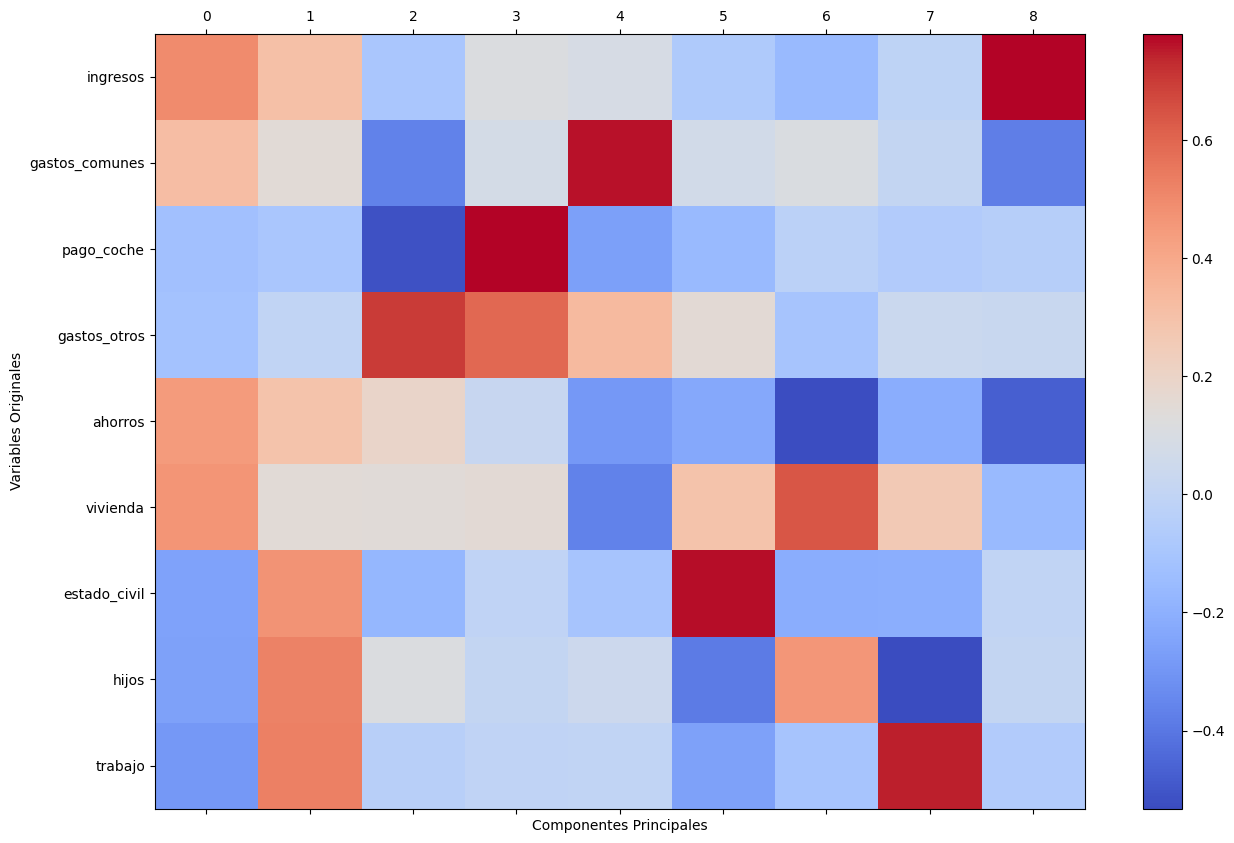

In [34]:
feature_names = df.drop(columns=['comprar']).columns

plt.figure(figsize=(15, 10))
plt.matshow(pca.components_.T, fignum=1, cmap='coolwarm', aspect='auto')
plt.yticks(range(len(feature_names)), feature_names)
plt.xticks(range(pca.n_components_))
plt.xlabel('Componentes Principales')
plt.ylabel('Variables Originales')
plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:

df_pca_components = pd.DataFrame(
    pca.components_, 
    columns=df_pca.columns,  
    index=[f'PC{i+1}' for i in range(pca.n_components_)]  
)


df_pca_components

NameError: name 'df_pca' is not defined

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [ ]:


# train_test_split con 20% para test y semilla 42
# miro el shape de X train, X test, y train, y test

(161, 9)
(41, 9)
(161,)
(41,)


In [ ]:


# pipeline con los pasos que se muestran en la figura de abajo
# Select k best con todas
# pca con 5 componentes
# random forest con max_depth 5, aunque max_depth no es muy necesario con el randomforest

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k='all')),
                ('pca', PCA(n_components=5)),
                ('classifier', RandomForestClassifier(max_depth=5))])

In [ ]:
# entreno el pipeline con train

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k='all')),
                ('pca', PCA(n_components=5)),
                ('classifier', RandomForestClassifier(max_depth=5))])

In [ ]:


# predigo con el pipeline en test
# calculo el accuracy en test
# calculo ma latriz de confusión en test

accuracy_score 0.7560975609756098
confusion_matrix
 [[21  3]
 [ 7 10]]


In [ ]:


# import LogisticRegression y SVM

In [28]:
pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('feature_selection', SelectKBest(k='all')),
                ('pca', PCA(n_components=5)),
                ('classifier', RandomForestClassifier(max_depth=5))])

In [ ]:
# probamos esta combinación de hiperparámetros, a ver qué tal salen las métricas
# si tenéis tiempo, podéis probar otras combinaciones, por si mejorasen

params_rf = {
    'scaler': [StandardScaler(), 'passthrough'],
    'feature_selection__k': [5,7,'all'],
    'pca__n_components': np.arange(1,5),
    'classifier__max_depth': np.arange(2,7)
}

params_log = {
    'scaler': [StandardScaler(), 'passthrough'],
    'feature_selection__k': [5,7,'all'],
    'pca__n_components': np.arange(1,5),
    'classifier': [LogisticRegression()],
    'classifier__C': [0.1,1,10]
}


params_svm = {
    'scaler': [StandardScaler(), 'passthrough'],
    'feature_selection__k': [5,7,'all'],
    'pca__n_components': np.arange(1,5),
    'classifier': [SVC()],
    'classifier__C': [0.1,1,10],
    'classifier__kernel': ['linear','rbf']
}

In [40]:
search_space= [
    params_rf,
    params_log,
    params_svm
]

In [41]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# gs = GridSearchCV(pipe, search_space, cv=5, scoring="accuracy", n_jobs=-1, verbose=2)

gs = RandomizedSearchCV(pipe, search_space, cv=3, n_iter=100, scoring="accuracy", n_jobs=-1, verbose=1)
# con cv = 5 mejoraría
gs.fit(X_train, y_train)


Fitting 3 folds for each of 100 candidates, totalling 300 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('feature_selection',
                                              SelectKBest(k='all')),
                                             ('pca', PCA(n_components=5)),
                                             ('classifier',
                                              RandomForestClassifier(max_depth=5))]),
                   n_iter=100, n_jobs=-1,
                   param_distributions=[{'classifier__max_depth': array([2, 3, 4, 5, 6]),
                                         'feature_selection__k': [5, 7, 'all'],
                                         'pca__n_components': array([...
                                         'classifier__C': [0.1, 1, 10],
                                         'feature_selection__k': [5, 7, 'all'],
                                         'pca__n_components': array([1, 2, 3, 4]),
                                         'scaler': [StandardScaler(),
                                                    'passthrough']},
                                        {'classifier': [SVC()],
                                         'classifier__C': [0.1, 1, 10],
                                         'classifier__kernel': ['linear',
                                                                'rbf'],
                                         'feature_selection__k': [5, 7, 'all'],
                                         'pca__n_components': array([1, 2, 3, 4]),
                                         'scaler': [StandardScaler(),
                                                    'passthrough']}],
                   scoring='accuracy', verbose=1)

In [43]:
print(gs.best_params_)
print(gs.best_score_)
print(gs.best_estimator_)

{'scaler': 'passthrough', 'pca__n_components': np.int64(3), 'feature_selection__k': 'all', 'classifier__kernel': 'linear', 'classifier__C': 10, 'classifier': SVC()}
0.9067085953878408
Pipeline(steps=[('scaler', 'passthrough'),
                ('feature_selection', SelectKBest(k='all')),
                ('pca', PCA(n_components=np.int64(3))),
                ('classifier', SVC(C=10, kernel='linear'))])


In [44]:
final_model = gs.best_estimator_.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
print("accuracy_score", accuracy_score(y_test, y_pred))
print("confusion_matrix\n", confusion_matrix(y_test, y_pred))

accuracy_score 0.7804878048780488
confusion_matrix
 [[21  3]
 [ 6 11]]


In [45]:
final_model

Pipeline(steps=[('scaler', 'passthrough'),
                ('feature_selection', SelectKBest(k='all')),
                ('pca', PCA(n_components=np.int64(3))),
                ('classifier', SVC(C=10, kernel='linear'))])

In [46]:
import pickle

In [47]:
pickle.dump(final_model, open("final_model.pkl", 'wb'))

In [48]:
modelo_importado = pickle.load(open('final_model.pkl', 'rb'))
modelo_importado

Pipeline(steps=[('scaler', 'passthrough'),
                ('feature_selection', SelectKBest(k='all')),
                ('pca', PCA(n_components=np.int64(3))),
                ('classifier', SVC(C=10, kernel='linear'))])